# LECTURE 2
**Topic:** Lines and circles on the complex plane; complex multiplication and division  
**Textbook References:** Section 1.3

---

## Key Points

- Two complex numbers can be multiplied by expressing each in the form $z = x + jy$, then using distributivity and the rule $j^2 = -1$ (i.e., $j$ is treated as the square root of $-1$).
- The product of two complex numbers with polar coordinates $(r_1, \theta_1)$ and $(r_2, \theta_2)$ is the complex number with polar coordinates $(r_1 r_2,\; \theta_1 + \theta_2)$.
- The product of a complex number $z$ and its conjugate $z^*$ equals the square modulus $|z|^2$.
- If $z$ has polar coordinates $(r, \theta)$, its inverse $z^{-1}$ has polar coordinates $(r^{-1}, -\theta)$.


---
## Theory and Examples

### 1. Geometry on the Complex Plane — Circles and Lines

The modulus $|z|$ represents the **length** of the vector $z$.  
Similarly, $|z_1 - z_2|$ gives the **distance** between points $z_1$ and $z_2$.

Using this concept:

- $|z - z_0| = a$ (where $a > 0$) is the set of points $z$ at a fixed distance $a$ from $z_0$.  
  This is a **circle of radius $a$ centered at $z_0$**.
  
- $|z - z_1| = |z - z_2|$ is the set of points equidistant from $z_1$ and $z_2$.  
  This is the **perpendicular bisector** of the line segment joining $z_1$ and $z_2$.

**Task:** Sketch the two curves:
$$|z - 3 + 4j| = 5 \\quad \\text{and} \\quad |z - 3| = |z + 4j|$$

> 💡 **Insight:** Rewrite $|z - 3 + 4j| = 5$ as $|z - (3 - 4j)| = 5$. This is a circle centered at $z_0 = 3 - 4j$ with radius $5$.  
> For the line: $|z - z_1| = |z - z_2|$ with $z_1 = 3$ and $z_2 = -4j$ gives the perpendicular bisector of the segment from $(3,0)$ to $(0,-4)$.


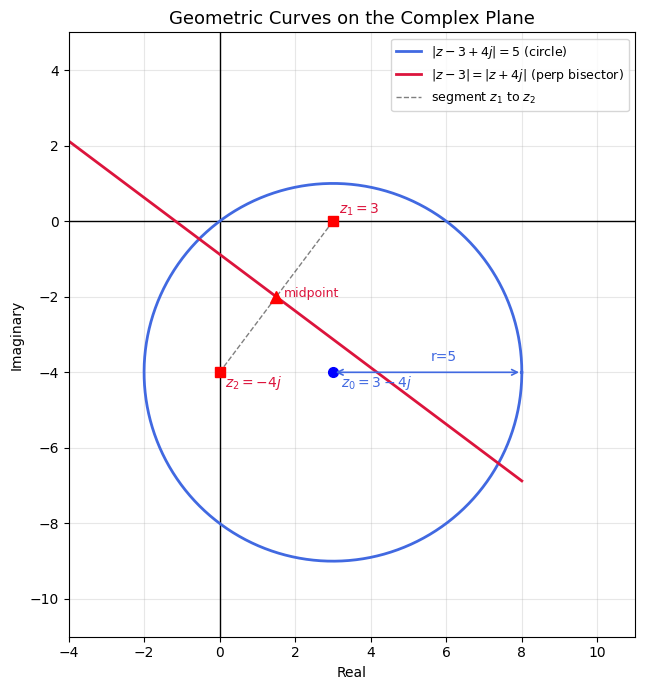

Midpoint = (1.5-2j)
|mid - 3| = 2.5000,  |mid + 4j| = 2.5000  (should be equal)


In [8]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 7))
ax.set_aspect('equal')
ax.axhline(0, color='black', lw=1); ax.axvline(0, color='black', lw=1)
ax.grid(True, alpha=0.3)

# --- Curve 1: |z - (3-4j)| = 5  (circle centered at 3-4j, radius 5) ---
z0 = 3 - 4j   # center
r  = 5         # radius
theta = np.linspace(0, 2*np.pi, 500)
circle_re = z0.real + r * np.cos(theta)
circle_im = z0.imag + r * np.sin(theta)
ax.plot(circle_re, circle_im, 'royalblue', lw=2, label=r'$|z - 3 + 4j| = 5$ (circle)')
ax.plot(z0.real, z0.imag, 'bo', ms=7)
ax.text(z0.real + 0.2, z0.imag - 0.4, r'$z_0=3-4j$', color='royalblue', fontsize=10)

# Annotate radius
ax.annotate('', xy=(z0.real + r, z0.imag), xytext=(z0.real, z0.imag),
            arrowprops=dict(arrowstyle='<->', color='royalblue', lw=1.2))
ax.text(z0.real + r/2 + 0.1, z0.imag + 0.3, 'r=5', color='royalblue', fontsize=10)

# --- Curve 2: |z - 3| = |z + 4j|  (perp bisector of segment (3,0)--(0,-4)) ---
# z1 = 3+0j, z2 = 0-4j  → midpoint = (1.5, -2)
# Direction of segment: (3,0)-(0,-4) = (3,4)  → normal direction: (4,-3) or (-4,3)
# Midpoint: (1.5, -2). Line: 3x + 4y = 3*1.5 + 4*(-2) = 4.5 - 8 = -3.5 → 3x + 4y = -3.5
x_line = np.linspace(-5, 8, 300)
# 3x + 4y = -3.5  → y = (-3.5 - 3x)/4
y_line = (-3.5 - 3*x_line) / 4
ax.plot(x_line, y_line, 'crimson', lw=2, label=r'$|z-3|=|z+4j|$ (perp bisector)')
ax.plot([3, 0], [0, -4], 'k--', lw=1, alpha=0.5, label='segment $z_1$ to $z_2$')
ax.plot(3, 0, 'rs', ms=7); ax.text(3.15, 0.2, r'$z_1=3$', fontsize=10, color='crimson')
ax.plot(0, -4, 'rs', ms=7); ax.text(0.15, -4.4, r'$z_2=-4j$', fontsize=10, color='crimson')
ax.plot(1.5, -2, 'r^', ms=8); ax.text(1.7, -2, 'midpoint', fontsize=9, color='crimson')

ax.set_xlim(-4, 11); ax.set_ylim(-11, 5)
ax.set_xlabel('Real'); ax.set_ylabel('Imaginary')
ax.set_title('Geometric Curves on the Complex Plane', fontsize=13)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

# Verify: midpoint of (3,0) and (0,-4) should be on the line
mid = complex(3,0)/2 + complex(0,-4)/2
dist1 = abs(mid - 3)
dist2 = abs(mid - (-4j))
print(f"Midpoint = {mid}")
print(f"|mid - 3| = {dist1:.4f},  |mid + 4j| = {dist2:.4f}  (should be equal)")

---
### 2. Complex Multiplication in Rectangular Form

The most common form for a complex number:
$$z = x + jy$$

With the convention $j^2 = -1$, multiplication proceeds by expanding and simplifying:

$$\\text{Example: } (5-2j)(3-4j) = 15 - 20j - 6j + 8j^2 = 15 - 26j - 8 = 7 - 26j$$

> ⚠️ **Common Mistake:** Forgetting to substitute $j^2 = -1$ after expanding. Always replace $j^2$ with $-1$.


In [9]:
# --- Complex multiplication in rectangular form ---
z1 = 5 - 2j
z2 = 3 - 4j

# Manual step-by-step
re_part = z1.real*z2.real - z1.imag*z2.imag   # ac - bd  (using j²=-1)
im_part = z1.real*z2.imag + z1.imag*z2.real   # ad + bc

print("=== Complex Multiplication: (5-2j)(3-4j) ===")
print(f"  Expand: ({z1.real})({z2.real}) + ({z1.real})({z2.imag}j) + ({z1.imag}j)({z2.real}) + ({z1.imag}j)({z2.imag}j)")
print(f"  = {z1.real*z2.real} + ({z1.real*z2.imag})j + ({z1.imag*z2.real})j + ({z1.imag*z2.imag})j²")
print(f"  = {z1.real*z2.real} + ({z1.real*z2.imag+z1.imag*z2.real})j + ({z1.imag*z2.imag})×(-1)  [since j²=-1]")
print(f"  = {re_part} + ({im_part})j")
print(f"  Python check: z1*z2 = {z1*z2}")

=== Complex Multiplication: (5-2j)(3-4j) ===
  Expand: (5.0)(3.0) + (5.0)(-4.0j) + (-2.0j)(3.0) + (-2.0j)(-4.0j)
  = 15.0 + (-20.0)j + (-6.0)j + (8.0)j²
  = 15.0 + (-26.0)j + (8.0)×(-1)  [since j²=-1]
  = 7.0 + (-26.0)j
  Python check: z1*z2 = (7-26j)


---
### 3. Complex Multiplication in Polar Form

If $z_1 = r_1(\cos\theta_1 + j\sin\theta_1)$ and $z_2 = r_2(\cos\theta_2 + j\sin\theta_2)$, then using the trig identities:
$$\cos(\theta_1+\theta_2) = \cos\theta_1\cos\theta_2 - \sin\theta_1\sin\theta_2$$
$$\sin(\theta_1+\theta_2) = \cos\theta_1\sin\theta_2 + \sin\theta_1\cos\theta_2$$

we obtain:
$$z_1 z_2 \text{ has modulus } r_1 r_2 \text{ and angle } \theta_1+\theta_2$$

> 💡 **Key Insight:** Polar multiplication = multiply magnitudes + add angles.


In [10]:
# --- Polar multiplication example ---
z1 = 5 - 2j
z2 = 3 - 4j

r1 = abs(z1); theta1 = np.angle(z1)
r2 = abs(z2); theta2 = np.angle(z2)

print("=== Polar Form ===")
print(f"  |z1| = sqrt(29) = {r1:.4f},  ∠z1 = {theta1:.4f} rad")
print(f"  |z2| = 5        = {r2:.4f},  ∠z2 = {theta2:.4f} rad")
print()

r_prod   = r1 * r2
theta_prod = theta1 + theta2
print(f"  |z1·z2| = {r1:.4f} × {r2:.4f} = {r_prod:.4f} = 5√29")
print(f"  ∠z1·z2  = {theta1:.4f} + ({theta2:.4f}) = {theta_prod:.4f} rad")
print()

# Convert back to Cartesian
re_prod = r_prod * np.cos(theta_prod)
im_prod = r_prod * np.sin(theta_prod)
print(f"  Cartesian: {r_prod:.4f}·(cos({theta_prod:.4f}) + j·sin({theta_prod:.4f}))")
print(f"           = {re_prod:.4f} + {im_prod:.4f}j")
print(f"  Python check: z1*z2 = {z1*z2}")
print()

# Extension: Powers
print("=== Extension: z1^5 · z2^2 ===")
r_ext   = r1**5 * r2**2
theta_ext = 5*theta1 + 2*theta2
result_ext = r_ext * (np.cos(theta_ext) + 1j*np.sin(theta_ext))
print(f"  |z1^5 · z2^2| = {r1:.4f}^5 × {r2:.4f}^2 = {r_ext:.4f}")
print(f"  ∠(z1^5·z2^2)  = 5×({theta1:.4f}) + 2×({theta2:.4f}) = {theta_ext:.4f} rad")
print(f"  Result (low precision): {re_prod:.0f} + {im_prod:.0f}j  (approx)")
print(f"  Result (exact):         {(z1**5 * z2**2).real:.0f} + {(z1**5 * z2**2).imag:.0f}j")
print(f"  Note: Low-precision result accumulates roundoff — see lecture text.")

=== Polar Form ===
  |z1| = sqrt(29) = 5.3852,  ∠z1 = -0.3805 rad
  |z2| = 5        = 5.0000,  ∠z2 = -0.9273 rad

  |z1·z2| = 5.3852 × 5.0000 = 26.9258 = 5√29
  ∠z1·z2  = -0.3805 + (-0.9273) = -1.3078 rad

  Cartesian: 26.9258·(cos(-1.3078) + j·sin(-1.3078))
           = 7.0000 + -26.0000j
  Python check: z1*z2 = (7-26j)

=== Extension: z1^5 · z2^2 ===
  |z1^5 · z2^2| = 5.3852^5 × 5.0000^2 = 113223.0901
  ∠(z1^5·z2^2)  = 5×(-0.3805) + 2×(-0.9273) = -3.7571 rad
  Result (low precision): 7 + -26j  (approx)
  Result (exact):         -92443 + 65374j
  Note: Low-precision result accumulates roundoff — see lecture text.


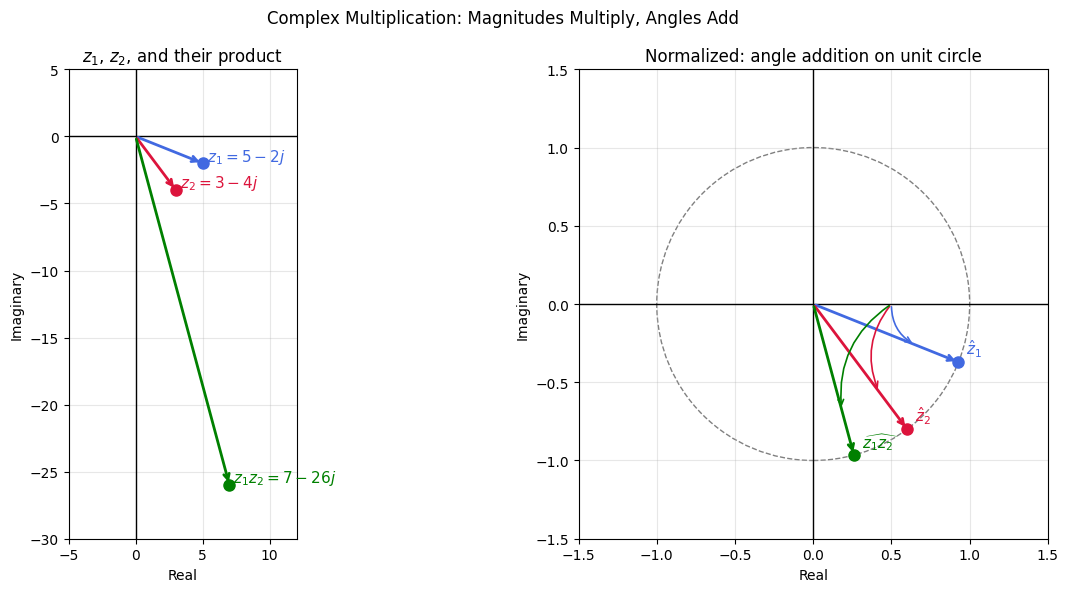

In [11]:
# --- Visualization: polar multiplication as rotation + scaling ---
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

z1 = 5 - 2j; z2 = 3 - 4j
prod = z1 * z2

def draw_vec(ax, z, col, lbl, off=(0.2, 0.2)):
    ax.annotate('', xy=(z.real, z.imag), xytext=(0,0),
                arrowprops=dict(arrowstyle='->', color=col, lw=2))
    ax.plot(z.real, z.imag, 'o', color=col, ms=8)
    ax.text(z.real+off[0], z.imag+off[1], lbl, color=col, fontsize=11)

# Left: z1, z2, and product
ax = axes[0]
ax.axhline(0, color='k',lw=1); ax.axvline(0, color='k',lw=1); ax.grid(True,alpha=0.3); ax.set_aspect('equal')
draw_vec(ax, z1, 'royalblue', r'$z_1=5-2j$', (0.3, 0.2))
draw_vec(ax, z2, 'crimson',   r'$z_2=3-4j$', (0.3, 0.2))
draw_vec(ax, prod, 'green',   r'$z_1 z_2=7-26j$', (0.3, 0.2))
ax.set_xlim(-5, 12); ax.set_ylim(-30, 5)
ax.set_title(r'$z_1$, $z_2$, and their product')
ax.set_xlabel('Real'); ax.set_ylabel('Imaginary')

# Right: unit circle showing angle addition
ax = axes[1]
circle = plt.Circle((0,0), 1, fill=False, color='gray', lw=1, ls='--')
ax.add_patch(circle)
ax.axhline(0, color='k',lw=1); ax.axvline(0, color='k',lw=1); ax.grid(True,alpha=0.3); ax.set_aspect('equal')
# Normalized vectors
for z, col, lbl in [(z1/abs(z1), 'royalblue', r'$\hat{z}_1$'), 
                     (z2/abs(z2), 'crimson', r'$\hat{z}_2$'),
                     (prod/abs(prod), 'green', r'$\widehat{z_1z_2}$')]:
    draw_vec(ax, z, col, lbl, (0.05, 0.05))
ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
ax.set_title('Normalized: angle addition on unit circle')
ax.set_xlabel('Real'); ax.set_ylabel('Imaginary')
# Annotate angles
for z, col in [(z1, 'royalblue'), (z2, 'crimson'), (prod, 'green')]:
    ang = np.angle(z)
    ax.annotate('', xy=(np.cos(ang)*0.7, np.sin(ang)*0.7), xytext=(0.5, 0),
                arrowprops=dict(arrowstyle='->', color=col, lw=1.2, 
                                connectionstyle='arc3,rad=0.3'))
plt.suptitle('Complex Multiplication: Magnitudes Multiply, Angles Add', fontsize=12)
plt.tight_layout(); plt.show()

---
### 4. Complex Division

Division uses the complex conjugate of the denominator:

$$\frac{z_1}{z_2} = \frac{z_1 \cdot z_2^*}{z_2 \cdot z_2^*} = \frac{z_1 z_2^*}{|z_2|^2}$$

**Example:** With $z_1 = 5-2j$ and $z_2 = 3-4j$:

$$\frac{5-2j}{3-4j} = \frac{(5-2j)(3+4j)}{(3-4j)(3+4j)} = \frac{(5-2j)(3+4j)}{3^2+4^2} = \frac{23+14j}{25} = \frac{23}{25} + j\frac{14}{25}$$

This uses the identity $zz^* = |z|^2$.

> ⚠️ **Common Mistake:** Multiplying numerator and denominator by $z_2$ instead of $z_2^*$. Always use the **complex conjugate** of the denominator.


In [12]:
z1 = 5 - 2j
z2 = 3 - 4j

# Step-by-step division
z2_conj = z2.conjugate()
numerator   = z1 * z2_conj
denominator = z2 * z2_conj   # = |z2|^2, always real

print("=== Complex Division: (5-2j)/(3-4j) ===")
print(f"  z2*  = {z2_conj}  (conjugate of z2)")
print(f"  Numerator:   (5-2j)(3+4j) = {numerator}")
print(f"  Denominator: (3-4j)(3+4j) = 3²+4² = {denominator.real:.0f}  (real!)")
print(f"  Result: {numerator}/{denominator.real:.0f} = {numerator/denominator.real}")
print(f"  = {numerator.real/denominator.real:.4f} + {numerator.imag/denominator.real:.4f}j")
print(f"  Python check: z1/z2 = {z1/z2}")
print()
print(f"  Verify identity zz* = |z|²:")
print(f"  z2·z2* = {z2*z2_conj} (should equal |z2|² = {abs(z2)**2})")

=== Complex Division: (5-2j)/(3-4j) ===
  z2*  = (3+4j)  (conjugate of z2)
  Numerator:   (5-2j)(3+4j) = (23+14j)
  Denominator: (3-4j)(3+4j) = 3²+4² = 25  (real!)
  Result: (23+14j)/25 = (0.92+0.56j)
  = 0.9200 + 0.5600j
  Python check: z1/z2 = (0.92+0.56j)

  Verify identity zz* = |z|²:
  z2·z2* = (25+0j) (should equal |z2|² = 25.0)


---
### 5. The Complex Conjugate and Its Properties

For $z = x + jy$, the complex conjugate is $z^* = x - jy$.

Key identity:
$$zz^* = (x+jy)(x-jy) = x^2 + y^2 = |z|^2$$

### 6. The Inverse in Polar Form

Since $z^{-1} = z^*/|z|^2$:

$$|z^{-1}| = \frac{|z|}{|z|^2} = |z|^{-1} \qquad \angle z^{-1} = \angle z^* = -\angle z$$

In polar form: **inversion flips the sign of the angle** and **inverts the magnitude**.

**Task:** Verify the above results. Plot $z$, $z^*$ and $z^{-1}$ for $z = 3-4j$.


=== For z = 3-4j ===
  z        = (3-4j)  |z|=5.0000  ∠z=-53.13°
  z*       = (3+4j)  |z*|=5.0000  ∠z*=53.13°
  z^(-1)   = 0.1200+0.1600j  |z^-1|=0.2000  ∠z^-1=53.13°

  Verify z·z* = |z|²:  (25+0j) = 25.0
  |z^-1| = 1/|z| = 0.2000  ✓
  ∠z^-1  = -∠z  = 53.13° ✓


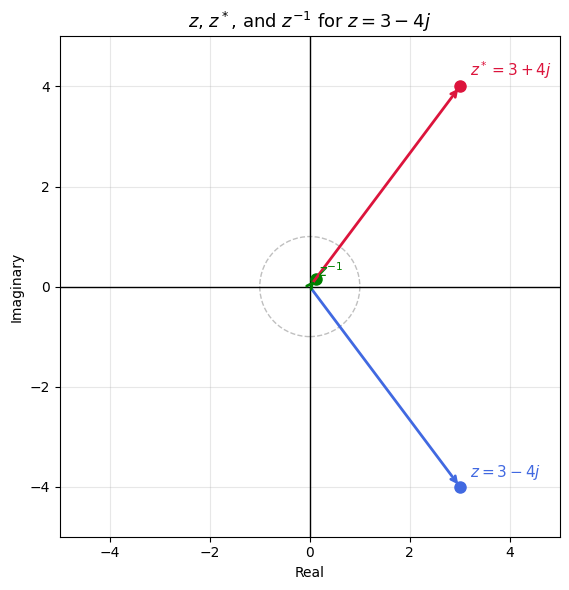

In [13]:
z = 3 - 4j

z_conj = z.conjugate()
z_inv  = 1 / z

print("=== For z = 3-4j ===")
print(f"  z        = {z}  |z|={abs(z):.4f}  ∠z={np.degrees(np.angle(z)):.2f}°")
print(f"  z*       = {z_conj}  |z*|={abs(z_conj):.4f}  ∠z*={np.degrees(np.angle(z_conj)):.2f}°")
print(f"  z^(-1)   = {z_inv:.4f}  |z^-1|={abs(z_inv):.4f}  ∠z^-1={np.degrees(np.angle(z_inv)):.2f}°")
print()
print(f"  Verify z·z* = |z|²:  {z*z_conj} = {abs(z)**2}")
print(f"  |z^-1| = 1/|z| = {1/abs(z):.4f}  ✓")
print(f"  ∠z^-1  = -∠z  = {np.degrees(-np.angle(z)):.2f}° ✓")

# Plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.axhline(0, color='black', lw=1); ax.axvline(0, color='black', lw=1)
ax.grid(True, alpha=0.3); ax.set_aspect('equal')
unit_c = plt.Circle((0,0), 1, fill=False, color='gray', ls='--', lw=1, alpha=0.5)
ax.add_patch(unit_c)

for zv, col, lbl, off in [(z, 'royalblue', r'$z=3-4j$', (0.2, 0.2)),
                           (z_conj, 'crimson', r'$z^*=3+4j$', (0.2, 0.2)),
                           (z_inv, 'green', r'$z^{-1}$', (0.04, 0.04))]:
    ax.annotate('', xy=(zv.real, zv.imag), xytext=(0,0),
                arrowprops=dict(arrowstyle='->', color=col, lw=2))
    ax.plot(zv.real, zv.imag, 'o', color=col, ms=8)
    ax.text(zv.real+off[0], zv.imag+off[1], lbl, color=col, fontsize=11)

ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)
ax.set_xlabel('Real'); ax.set_ylabel('Imaginary')
ax.set_title(r'$z$, $z^*$, and $z^{-1}$ for $z=3-4j$', fontsize=13)
plt.tight_layout(); plt.show()

---
## Summary & Common Mistakes

| Operation | Rectangular Form | Polar Form |
|---|---|---|
| Multiplication | Expand and use $j^2=-1$ | Multiply $r$'s, add $\\theta$'s |
| Division | Multiply by $z_2^*/|z_2|^2$ | Divide $r$'s, subtract $\\theta$'s |
| Conjugate | Negate imaginary part | Negate angle |
| Inverse | $z^*/|z|^2$ | $(|z|^{-1}, -\\theta)$ |

### ⚠️ Mistakes to Avoid
1. In multiplication: forgetting $j^2 = -1$ after expanding.
2. In division: multiplying by $z_2$ instead of $z_2^*$.
3. Confusing $z^*$ (conjugate, negate Im part) with $-z$ (negate both parts).
4. Assuming $|z_1 + z_2| = |z_1| + |z_2|$ — this is **not** true in general (triangle inequality says $\\leq$).
